<a href="https://colab.research.google.com/github/juanigr/Ayudantias/blob/main/code/modelos_lineales_y_regresion_logistica_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos lineales y regresión logística en R para Google Colab

**Curso:** Minería de Datos 2026

**Objetivo:** aprender a construir, interpretar y evaluar modelos de regresión lineal simple, regresión lineal múltiple y regresión logística en R, avanzando desde ejemplos básicos hasta análisis más completos.

## Contenidos

- Preparación del entorno de R dentro de Colab
- Regresión lineal simple
- Regresión lineal múltiple
- Interacciones, diagnóstico y validación básica
- Regresión logística binaria
- Evaluación con matriz de confusión, ROC y AUC
- Ejercicios para estudiantes
- Mini proyecto integrador


## 0. Preparación de Colab con librerias de R

> Ejecuta estas celdas primero y en orden.


In [1]:


install_if_missing <- function(pkgs) {
  missing_pkgs <- pkgs[!(pkgs %in% installed.packages()[, "Package"])]
  if (length(missing_pkgs) > 0) {
    install.packages(missing_pkgs, repos = "https://cloud.r-project.org")
  }
}

install_if_missing(c("ggplot2", "dplyr", "broom", "pROC"))

#install.packages("GGally")

library(ggplot2)
library(dplyr)
library(broom)
library(pROC)

set.seed(123)
cat("Paquetes cargados correctamente.\n")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




Paquetes cargados correctamente.


In [2]:
install.packages("GGally")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’




## 1. Recordatorio conceptual

### Regresión lineal simple

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

### Regresión lineal múltiple

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \varepsilon
$$

### Regresión logística

$$
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p
$$

donde $p = P(Y=1)$.


## 2. Regresión lineal simple: ejemplo básico con `women`

Pregunta:

> ¿Cómo cambia el peso esperado a medida que aumenta la estatura?


In [3]:
#dataset women
data(women)
head(women)
glimpse(women)

,height,weight
,<dbl>,<dbl>
1,58,115
2,59,117
3,60,120
4,61,123
5,62,126
6,63,129


Rows: 15
Columns: 2
$ height <dbl> 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72
$ weight <dbl> 115, 117, 120, 123, 126, 129, 132, 135, 139, 142, 146, 150, 154…


In [4]:
summary(women)
mean(women$height)
mean(women$weight)

     height         weight     
 Min.   :58.0   Min.   :115.0  
 1st Qu.:61.5   1st Qu.:124.5  
 Median :65.0   Median :135.0  
 Mean   :65.0   Mean   :136.7  
 3rd Qu.:68.5   3rd Qu.:148.0  
 Max.   :72.0   Max.   :164.0  

[1] 65

[1] 136.7333

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


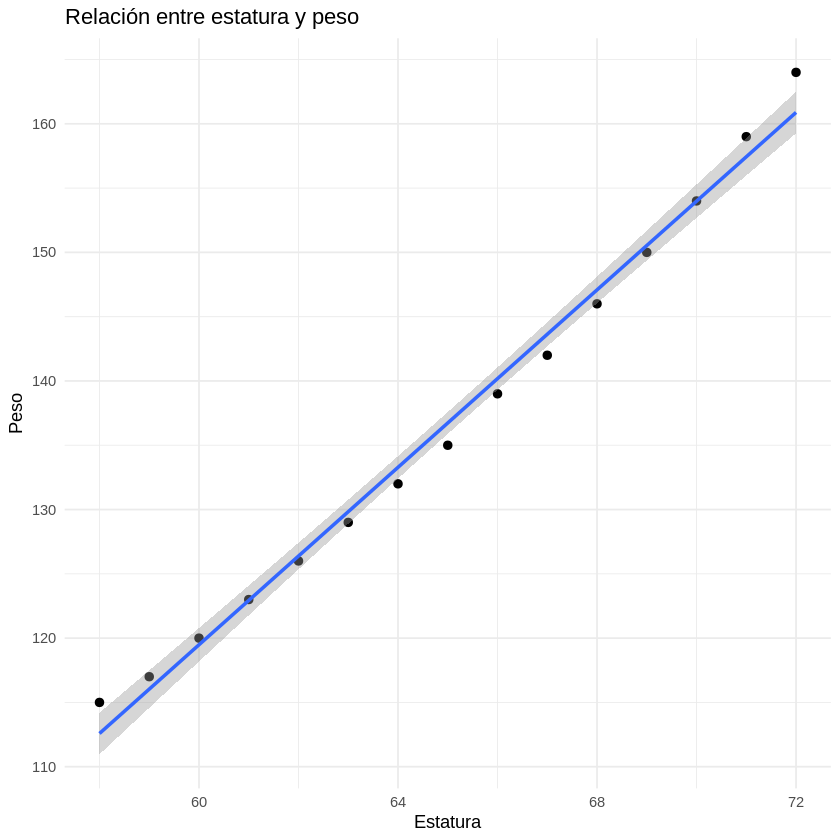

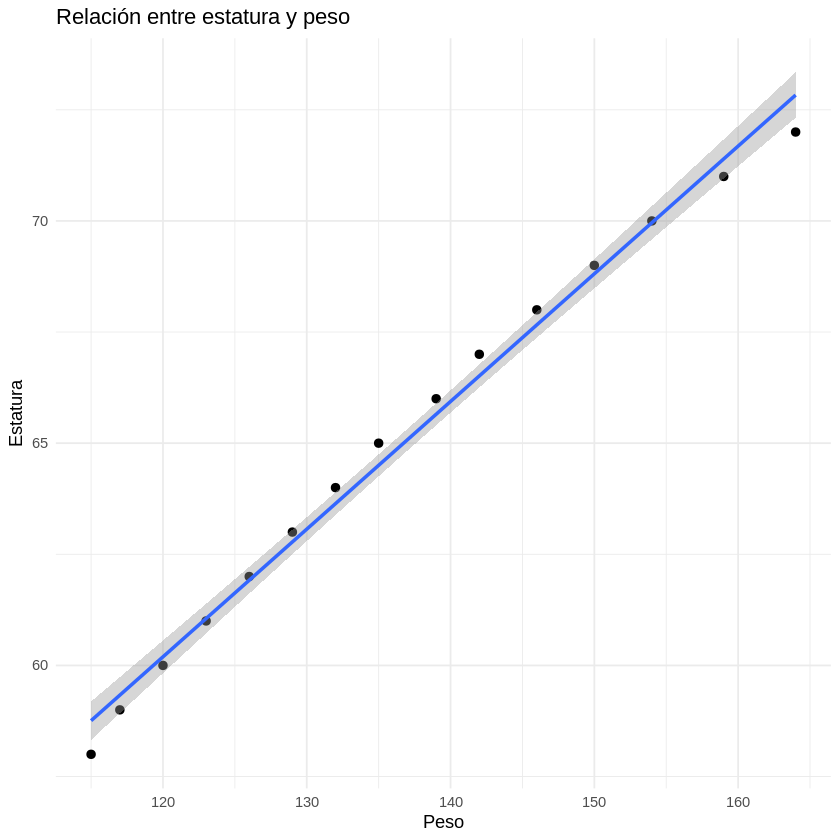

In [5]:
ggplot(women, aes(x = height, y = weight)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relación entre estatura y peso",
    x = "Estatura",
    y = "Peso"
  ) +
  theme_minimal()

ggplot(women, aes(x = weight, y = height)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relación entre estatura y peso",
    x = "Peso",
    y = "Estatura"
  ) +
  theme_minimal()


In [6]:
modelo_simple <- lm(weight ~ height, data = women)
summary(modelo_simple)


Call:
lm(formula = weight ~ height, data = women)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.7333 -1.1333 -0.3833  0.7417  3.1167 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -87.51667    5.93694  -14.74 1.71e-09 ***
height        3.45000    0.09114   37.85 1.09e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.525 on 13 degrees of freedom
Multiple R-squared:  0.991,	Adjusted R-squared:  0.9903 
F-statistic:  1433 on 1 and 13 DF,  p-value: 1.091e-14


In [7]:
#convertir el modelo en data.frames para posterior utilizacion
tidy(modelo_simple)
#con glance
glance(modelo_simple)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-87.51667,5.9369440,-14.74103,1.711082e-09
height,3.45000,0.0911365,37.85531,1.090973e-14


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.9910098,0.9903183,1.525005,1433.024,1.090973e-14,1,-26.54079,59.08158,61.20573,30.23333,13,15


In [8]:
cor.test(women$height,women$weight)


	Pearson's product-moment correlation

data:  women$height and women$weight
t = 37.855, df = 13, p-value = 1.091e-14
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9860970 0.9985447
sample estimates:
      cor 
0.9954948 


In [9]:
#predecir con nuestro modelo
#indicamos las alturas
nuevas_alturas <- data.frame(height = c(50, 65, 75))
#usamos la funcion predict, nuestro modelo, datos nuevos y solicitamos intervalos de confianza para las predicciones
predict(modelo_simple, newdata = nuevas_alturas, interval = "confidence")
#fit es la estimacion del model y lwr y upr los valores asociados al intervalo de confianza de la predccion


,fit,lwr,upr
1,84.98333,81.90994,88.05673
2,136.73333,135.88268,137.58399
3,171.23333,169.08854,173.37812


### Interpretación

- La pendiente indica cuánto cambia el peso esperado por cada unidad adicional de estatura.
- El valor-p evalúa si la pendiente es significativamente distinta de 0.
- El $R^2$ indica qué proporción de la variabilidad del peso es explicada por la estatura.


### Ejercicios 1

1. Ajusta el modelo inverso: `height ~ weight`.  
2. Interpreta la nueva pendiente.  
3. Compara ambos $R^2$.  
4. Predice la estatura para pesos 120, 140 y 160.



Call:
lm(formula = height ~ weight, data = women)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.83233 -0.26249  0.08314  0.34353  0.49790 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 25.723456   1.043746   24.64 2.68e-12 ***
weight       0.287249   0.007588   37.85 1.09e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.44 on 13 degrees of freedom
Multiple R-squared:  0.991,	Adjusted R-squared:  0.9903 
F-statistic:  1433 on 1 and 13 DF,  p-value: 1.091e-14



	Pearson's product-moment correlation

data:  women$weight and women$height
t = 37.855, df = 13, p-value = 1.091e-14
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9860970 0.9985447
sample estimates:
      cor 
0.9954948 


function (object, ...) 
UseMethod("coef")
<bytecode: 0x574d069bc6a8>
<environment: namespace:stats>

,fit,lwr,upr
1,84.98333,81.90994,88.05673
2,136.73333,135.88268,137.58399
3,171.23333,169.08854,173.37812


`geom_smooth()` using formula = 'y ~ x'


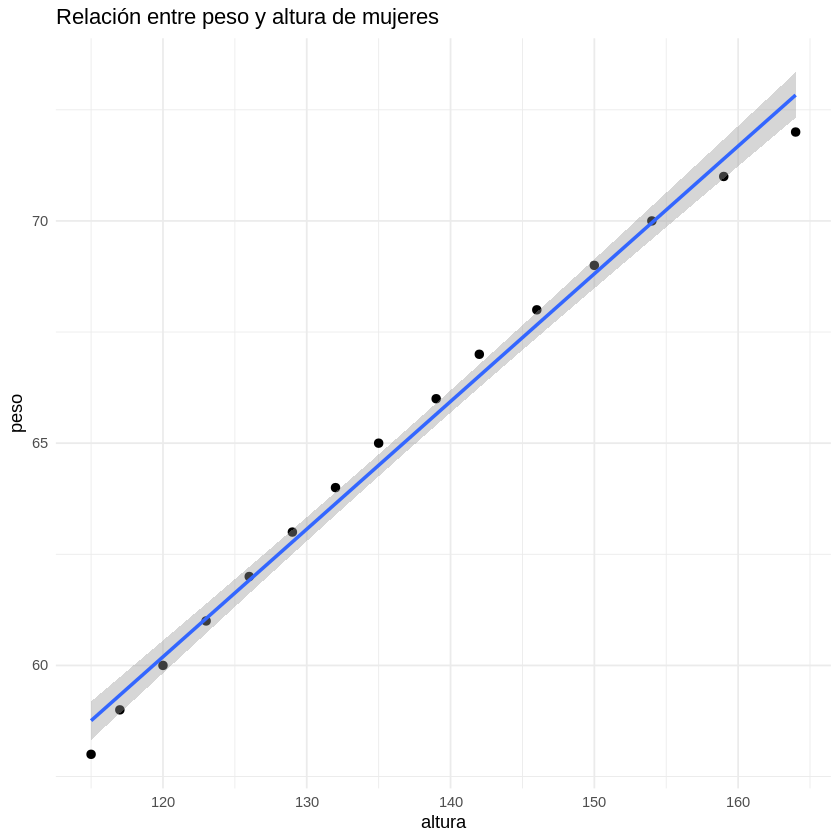

In [53]:
# Escribe aquí tu solución

modelo_altura <- lm(height ~ weight, data=women)
summary(modelo_altura)
cor.test(women$weight,women$height)
coeficientes <- modelo_altura$coefficients
coefficients
predict(modelo_simple, newdata = nuevas_alturas, interval = "confidence")

women %>%
  ggplot(aes(x = weight, y = height)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relación entre peso y altura de mujeres",
    x = "altura",
    y = "peso"
  ) +
  theme_minimal()


## 3. Regresión lineal múltiple: ejemplo intermedio con `mtcars`

Modelaremos `mpg` usando:

- `wt`: peso del auto
- `hp`: caballos de fuerza
- `qsec`: tiempo en 1/4 de milla
- `am`: tipo de transmisión


In [11]:
data(mtcars)
glimpse(mtcars)
table(mtcars$am)
table(mtcars$cyl)
mtcars %>% select(am) %>% group_by(am) %>% summarise(n=n())

Rows: 32
Columns: 11
$ mpg  <dbl> 21.0, 21.0, 22.8, 21.4, 18.7, 18.1, 14.3, 24.4, 22.8, 19.2, 17.8,…
$ cyl  <dbl> 6, 6, 4, 6, 8, 6, 8, 4, 4, 6, 6, 8, 8, 8, 8, 8, 8, 4, 4, 4, 4, 8,…
$ disp <dbl> 160.0, 160.0, 108.0, 258.0, 360.0, 225.0, 360.0, 146.7, 140.8, 16…
$ hp   <dbl> 110, 110, 93, 110, 175, 105, 245, 62, 95, 123, 123, 180, 180, 180…
$ drat <dbl> 3.90, 3.90, 3.85, 3.08, 3.15, 2.76, 3.21, 3.69, 3.92, 3.92, 3.92,…
$ wt   <dbl> 2.620, 2.875, 2.320, 3.215, 3.440, 3.460, 3.570, 3.190, 3.150, 3.…
$ qsec <dbl> 16.46, 17.02, 18.61, 19.44, 17.02, 20.22, 15.84, 20.00, 22.90, 18…
$ vs   <dbl> 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,…
$ am   <dbl> 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,…
$ gear <dbl> 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 3,…
$ carb <dbl> 4, 4, 1, 1, 2, 1, 4, 2, 2, 4, 4, 3, 3, 3, 4, 4, 4, 1, 2, 1, 1, 2,…



 0  1 
19 13 


 4  6  8 
11  7 14 

am,n
<dbl>,<int>
0,19
1,13


In [57]:
head(table)
mtcars2 <- mtcars %>%
  mutate(
    am = factor(am, labels = c("Automática", "Manual")),
    cyl = factor(cyl)
  )

head(mtcars2)
mediana_am <- mean(mtcars$am)
mediana_am

                                                                             
1 function (..., exclude = if (useNA == "no") c(NA, NaN), useNA = c("no",    
2     "ifany", "always"), dnn = list.names(...), deparse.level = 1)          
3 {                                                                          
4     list.names <- function(...) {                                          
5         l <- as.list(substitute(list(...)))[-1L]                           
6         if (length(l) == 1L && is.list(..1) && !is.null(nm <- names(..1))) 

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,Manual,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,Manual,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,Manual,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,Automática,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,Automática,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,Automática,3,1


[1] 0.40625

In [58]:
mediana_am <- mean(mtcars$am)
mediana_am

[1] 0.40625

In [13]:
glimpse(mtcars2)

mtcars2 %>% select(am) %>% group_by(am) %>% summarise(n=n())

Rows: 32
Columns: 11
$ mpg  <dbl> 21.0, 21.0, 22.8, 21.4, 18.7, 18.1, 14.3, 24.4, 22.8, 19.2, 17.8,…
$ cyl  <fct> 6, 6, 4, 6, 8, 6, 8, 4, 4, 6, 6, 8, 8, 8, 8, 8, 8, 4, 4, 4, 4, 8,…
$ disp <dbl> 160.0, 160.0, 108.0, 258.0, 360.0, 225.0, 360.0, 146.7, 140.8, 16…
$ hp   <dbl> 110, 110, 93, 110, 175, 105, 245, 62, 95, 123, 123, 180, 180, 180…
$ drat <dbl> 3.90, 3.90, 3.85, 3.08, 3.15, 2.76, 3.21, 3.69, 3.92, 3.92, 3.92,…
$ wt   <dbl> 2.620, 2.875, 2.320, 3.215, 3.440, 3.460, 3.570, 3.190, 3.150, 3.…
$ qsec <dbl> 16.46, 17.02, 18.61, 19.44, 17.02, 20.22, 15.84, 20.00, 22.90, 18…
$ vs   <dbl> 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,…
$ am   <fct> Manual, Manual, Manual, Automática, Automática, Automática, Autom…
$ gear <dbl> 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 3,…
$ carb <dbl> 4, 4, 1, 1, 2, 1, 4, 2, 2, 4, 4, 3, 3, 3, 4, 4, 4, 1, 2, 1, 1, 2,…


am,n
<fct>,<int>
Automática,19
Manual,13


In [ ]:
#sumary de las variables seleccionadas
head(mtcars2)

head(mtcars2[, c("mpg", "wt", "hp", "qsec", "am")])

summary(mtcars2[, c("mpg", "wt", "hp", "qsec", "am")])
#como es el equivalente con select?

In [60]:
summary(mtcars2[,c("mpg", "wt", "hp")]) # con esto resumimos un conjunto de variables seleccionados

      mpg              wt              hp       
 Min.   :10.40   Min.   :1.513   Min.   : 52.0  
 1st Qu.:15.43   1st Qu.:2.581   1st Qu.: 96.5  
 Median :19.20   Median :3.325   Median :123.0  
 Mean   :20.09   Mean   :3.217   Mean   :146.7  
 3rd Qu.:22.80   3rd Qu.:3.610   3rd Qu.:180.0  
 Max.   :33.90   Max.   :5.424   Max.   :335.0  

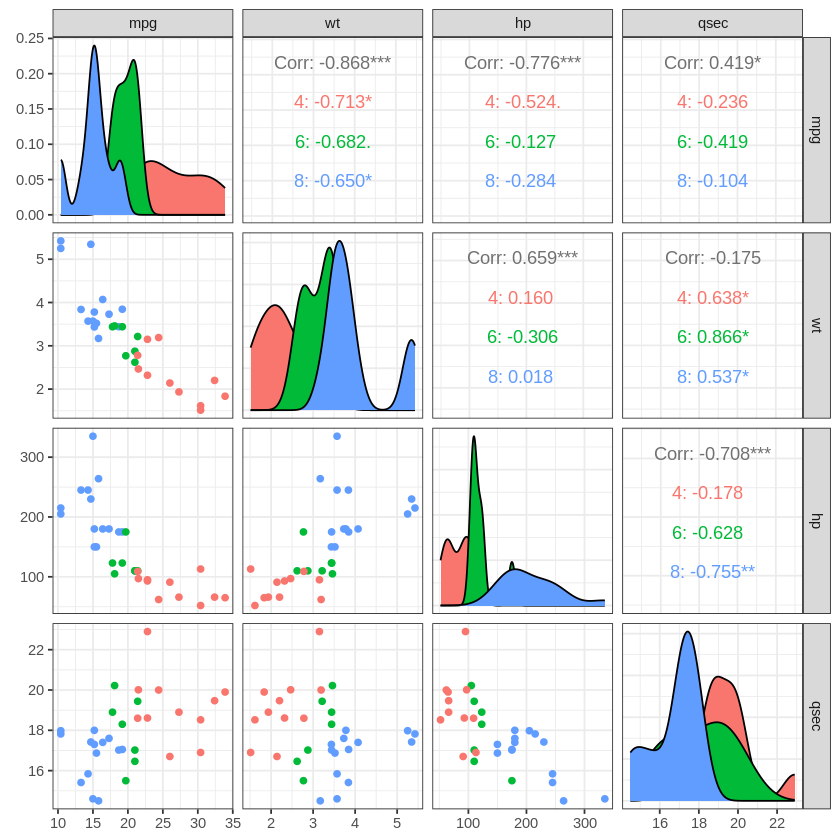

In [15]:
#ggpairs paquete ggally
library(GGally)
mtcars2 %>% select(mpg,wt,hp,qsec,cyl) %>%
#ggpairs(columns = 1:4) + theme_bw() graficos más raros
ggpairs(columns = 1:4, ggplot2::aes(colour = cyl)) + theme_bw()

#pairs es una funcion base de R para
#pairs(mtcars2[, c("mpg", "wt", "hp", "qsec")],
#      main = "Relaciones entre variables numéricas")
#ggpairs


In [64]:
# Modelos de regresión lineal múltiple
modelo_multiple_1 <- lm(mpg ~ wt + hp + qsec, data = mtcars2)
modelo_multiple_2 <- lm(mpg ~ wt + hp, data = mtcars2)

# Resumen de los modelos
summary(modelo_multiple_1)
summary(modelo_multiple_2)

# Comparación usando AIC
# Menor AIC indica mejor equilibrio entre ajuste del modelo y complejidad
AIC(modelo_multiple_1, modelo_multiple_2)

# Comparación usando BIC
# Menor BIC indica mejor equilibrio entre ajuste y complejidad,
# penalizando más fuerte la cantidad de variables que el AIC
BIC(modelo_multiple_1, modelo_multiple_2)

# Comparamos los modelos usando AIC.
# El modelo con menor AIC presenta mejor equilibrio entre ajuste y complejidad.

# También comparamos usando BIC.
# El BIC penaliza más la cantidad de parámetros, por lo que suele favorecer modelos más parsimoniosos.


Call:
lm(formula = mpg ~ wt + hp + qsec, data = mtcars2)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.8591 -1.6418 -0.4636  1.1940  5.6092 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 27.61053    8.41993   3.279  0.00278 ** 
wt          -4.35880    0.75270  -5.791 3.22e-06 ***
hp          -0.01782    0.01498  -1.190  0.24418    
qsec         0.51083    0.43922   1.163  0.25463    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.578 on 28 degrees of freedom
Multiple R-squared:  0.8348,	Adjusted R-squared:  0.8171 
F-statistic: 47.15 on 3 and 28 DF,  p-value: 4.506e-11



Call:
lm(formula = mpg ~ wt + hp, data = mtcars2)

Residuals:
   Min     1Q Median     3Q    Max 
-3.941 -1.600 -0.182  1.050  5.854 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 37.22727    1.59879  23.285  < 2e-16 ***
wt          -3.87783    0.63273  -6.129 1.12e-06 ***
hp          -0.03177    0.00903  -3.519  0.00145 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.593 on 29 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8148 
F-statistic: 69.21 on 2 and 29 DF,  p-value: 9.109e-12


,df,AIC
,<dbl>,<dbl>
modelo_multiple_1,5,157.1426
modelo_multiple_2,4,156.6523


,df,BIC
,<dbl>,<dbl>
modelo_multiple_1,5,164.4713
modelo_multiple_2,4,162.5153


In [68]:
modelo_multiple_2 <- lm(mpg ~ wt + hp + qsec + am, data = mtcars2) # agregamos una variable extra am
summary(modelo_multiple_2)
AIC(modelo_multiple_2)


Call:
lm(formula = mpg ~ wt + hp + qsec + am, data = mtcars2)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.4975 -1.5902 -0.1122  1.1795  4.5404 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept) 17.44019    9.31887   1.871  0.07215 . 
wt          -3.23810    0.88990  -3.639  0.00114 **
hp          -0.01765    0.01415  -1.247  0.22309   
qsec         0.81060    0.43887   1.847  0.07573 . 
amManual     2.92550    1.39715   2.094  0.04579 * 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.435 on 27 degrees of freedom
Multiple R-squared:  0.8579,	Adjusted R-squared:  0.8368 
F-statistic: 40.74 on 4 and 27 DF,  p-value: 4.589e-11


[1] 154.3274

In [69]:
library(broom)
library(dplyr)

modelo_simple <- lm(mpg ~ wt + hp, data = mtcars2)

modelo_completo <- lm(mpg ~ wt + hp + qsec, data = mtcars2)

# Comparación ANOVA
anova(modelo_simple, modelo_completo)

# Comparación con AIC y BIC
AIC(modelo_simple, modelo_completo)
BIC(modelo_simple, modelo_completo)

# Métricas generales
metricas_modelos <- tibble(
  modelo = c("Simple", "Completo"),
  R2 = c(
    summary(modelo_simple)$r.squared,
    summary(modelo_completo)$r.squared
  ),
  R2_ajustado = c(
    summary(modelo_simple)$adj.r.squared,
    summary(modelo_completo)$adj.r.squared
  ),
  RMSE = c(
    sqrt(mean(residuals(modelo_simple)^2)),
    sqrt(mean(residuals(modelo_completo)^2))
  ),
  MAE = c(
    mean(abs(residuals(modelo_simple))),
    mean(abs(residuals(modelo_completo)))
  ),
  AIC = c(
    AIC(modelo_simple),
    AIC(modelo_completo)
  ),
  BIC = c(
    BIC(modelo_simple),
    BIC(modelo_completo)
  )
)

metricas_modelos

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,29,195.0478,NA,NA,NA,NA
2,28,186.0593,1,8.988458,1.35267,0.2546284


,df,AIC
,<dbl>,<dbl>
modelo_simple,4,156.6523
modelo_completo,5,157.1426


,df,BIC
,<dbl>,<dbl>
modelo_simple,4,162.5153
modelo_completo,5,164.4713


modelo,R2,R2_ajustado,RMSE,MAE,AIC,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,0.8267855,0.8148396,2.468854,1.901484,156.6523,162.5153
Completo,0.8347678,0.8170643,2.411297,1.873381,157.1426,164.4713


### Interpretación estadística

Como el p-valor = 0.0458 < 0.05, entonces:

hay evidencia estadísticamente significativa al 5%
el modelo 2 ajusta mejor que el modelo 1
la variable adicional incorporada en el modelo 2 aporta información útil para explicar la respuesta

#### Interpretación en palabras simples

El segundo modelo reduce el error residual de:

186.06 a 160.07

Esa reducción no parece deberse solo al azar, así que conviene quedarse con el modelo 2, al menos bajo un criterio de significancia del 5%.

### Ojo importante

Esto no significa  que el modelo 2 sea “el mejor posible”, solo que es mejor que el modelo.

## Nota de ANOVA

ANOVA se usa mucho para comparar medias, pero en el fondo lo que hace es comparar variabilidad. Por eso también sirve para comparar modelos lineales.

### Idea central de ANOVA

ANOVA significa Analysis of Variance. La lógica es:

1. separar la variabilidad total
2. ver cuánta variabilidad explica el modelo
3. comparar esa parte explicada con la que queda como error

El estadístico F siempre compara una razón de varianzas.

Entonces que esta preguntando estadisticamente cuando usamos ```anova(m1, m2)```?

1. ¿El modelo más complejo reduce el error residual de manera significativa respecto al modelo más simple?
2. ¿Las variables extra que agregué explican una cantidad importante de variación en la respuesta?


Compara dos cosas:

1. RSS del modelo simple: error que queda sin explicar
2. RSS del modelo complejo: error que queda después de agregar más predictores

Si el modelo complejo baja mucho el RSS, entonces esas variables nuevas aportan.

- La hipótesis nula es:

Las variables adicionales no mejoran el modelo.

- La alternativa es:

Las variables adicionales sí mejoran el modelo.

En comparación de modelos, ***ANOVA*** evalúa si un modelo más complejo explica significativamente más variabilidad que un modelo más simple.

In [19]:
tidy(modelo_multiple_2)
glance(modelo_multiple_2)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),17.44019110,9.3188688,1.871492,0.072149342
wt,-3.23809682,0.8898986,-3.638726,0.001141407
hp,-0.01764654,0.0141506,-1.247052,0.223087932
qsec,0.81060254,0.4388703,1.847021,0.075731202
amManual,2.92550394,1.3971471,2.093913,0.045790788


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.857851,0.8367919,2.434828,40.73539,4.589395e-11,4,-71.16368,154.3274,163.1218,160.0665,27,32


In [70]:
# Prediccion de nuevos datos
nuevos_autos <- data.frame(
  wt = c(2.2, 3.0),
  hp = c(110, 180),
  qsec = c(18.5, 16.8),
  am = factor(c("Manual", "Automática"), levels = levels(mtcars2$am))
)

predict(modelo_multiple_2, newdata = nuevos_autos, interval = "prediction")
head(nuevos_autos)

,fit,lwr,upr
1,26.29691,21.05281,31.54101
2,18.16765,12.75854,23.57675


,wt,hp,qsec,am
,<dbl>,<dbl>,<dbl>,<fct>
1,2.2,110,18.5,Manual
2,3.0,180,16.8,Automática


### A recordar

- Un coeficiente en regresión múltiple se interpreta manteniendo constantes las demás variables.
- Las variables categóricas como `am` se incorporan automáticamente mediante variables indicadoras.
- La comparación entre modelos permite discutir si agregar variables mejora el ajuste.


### Ejercicios 2

1. Ajusta un modelo con `mpg ~ wt + hp + am`.  
2. Compara ese modelo con `mpg ~ wt + hp + qsec + am`.  
3. ¿Cuál parece mejor según $R^2$ ajustado y significancia?  
4. Interpreta el efecto de `am` en palabras.  
5. Haz una predicción para un auto manual con `wt = 2.5`, `hp = 120`, `qsec = 18`.


In [71]:
# Escribe aquí tu modelo

modelo_ej2 <- lm(mpg ~ wt + hp + am, data = mtcars2)
summary(modelo_ej2)
glance(modelo_ej2)
predict(modelo_ej2, interval = "prediction")



Call:
lm(formula = mpg ~ wt + hp + am, data = mtcars2)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.4221 -1.7924 -0.3788  1.2249  5.5317 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 34.002875   2.642659  12.867 2.82e-13 ***
wt          -2.878575   0.904971  -3.181 0.003574 ** 
hp          -0.037479   0.009605  -3.902 0.000546 ***
amManual     2.083710   1.376420   1.514 0.141268    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.538 on 28 degrees of freedom
Multiple R-squared:  0.8399,	Adjusted R-squared:  0.8227 
F-statistic: 48.96 on 3 and 28 DF,  p-value: 2.908e-11


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.8398903,0.8227357,2.537512,48.96003,2.907872e-11,3,-73.06742,156.1348,163.4635,180.2911,28,32


Warning message in predict.lm(modelo_ej2, interval = "prediction"):
“predictions on current data refer to _future_ responses
”


,fit,lwr,upr
Mazda RX4,24.422058,18.987359,29.85676
Mazda RX4 Wag,23.688021,18.179367,29.19667
Datsun 710,25.922769,20.499622,31.34592
Hornet 4 Drive,20.625595,15.235886,26.01530
Hornet Sportabout,17.541799,12.143349,22.94025
Valiant,20.107738,14.715396,25.50008
Duster 360,14.544073,8.868079,20.22007
Merc 240D,22.496539,16.980950,28.01213
Merc 230,21.374884,15.958217,26.79155
Merc 280,19.490692,14.131352,24.85003


## 4. Regresión lineal avanzada: interacciones, diagnóstico y validación

Aquí revisaremos:

- interacción entre variables
- revisión visual de supuestos
- evaluación simple en train/test


In [22]:
modelo_interaccion <- lm(mpg ~ wt * am + hp, data = mtcars2)
summary(modelo_interaccion)


Call:
lm(formula = mpg ~ wt * am + hp, data = mtcars2)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.0639 -1.3315 -0.9347  1.2180  5.0822 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 30.947333   2.723411  11.363 8.55e-12 ***
wt          -2.515586   0.844497  -2.979  0.00605 ** 
amManual    11.554813   4.023277   2.872  0.00784 ** 
hp          -0.026949   0.009796  -2.751  0.01048 *  
wt:amManual -3.577910   1.442796  -2.480  0.01968 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.332 on 27 degrees of freedom
Multiple R-squared:  0.8696,	Adjusted R-squared:  0.8503 
F-statistic: 45.01 on 4 and 27 DF,  p-value: 1.451e-11


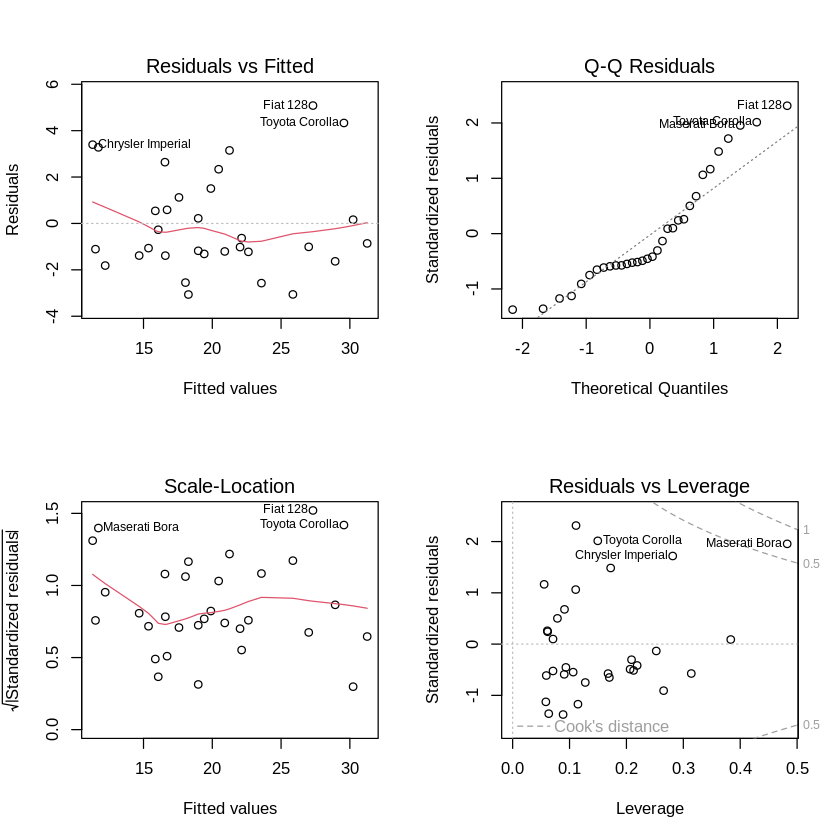

In [23]:
par(mfrow = c(2, 2))
plot(modelo_interaccion)
par(mfrow = c(1, 1))


In [24]:
set.seed(123)
#entrenar el modelo con el 70% de los datos disponibles
idx_train <- sample(seq_len(nrow(mtcars2)), size = round(0.7 * nrow(mtcars2)))
#realizamos la particion de los datos en entrenamineto y test
train_lm <- mtcars2[idx_train, ]
test_lm  <- mtcars2[-idx_train, ]
#creamos el modelo
modelo_train <- lm(mpg ~ wt + hp + qsec + am, data = train_lm)
#evaluamos las predicciones del modelo
pred_test <- predict(modelo_train, newdata = test_lm)
#determinamos el error cuadratico medio
rmse <- function(obs, pred) sqrt(mean((obs - pred)^2))
rmse(test_lm$mpg, pred_test)

[1] 2.124541

,observado,predicho
,<dbl>,<dbl>
Mazda RX4,21.0,23.65
Mazda RX4 Wag,21.0,23.35
Hornet 4 Drive,21.4,20.95
Valiant,18.1,20.98
Merc 450SE,16.4,14.99
Merc 450SL,17.3,16.25
Lincoln Continental,10.4,10.38
Toyota Corona,21.5,24.10
Camaro Z28,13.3,12.61


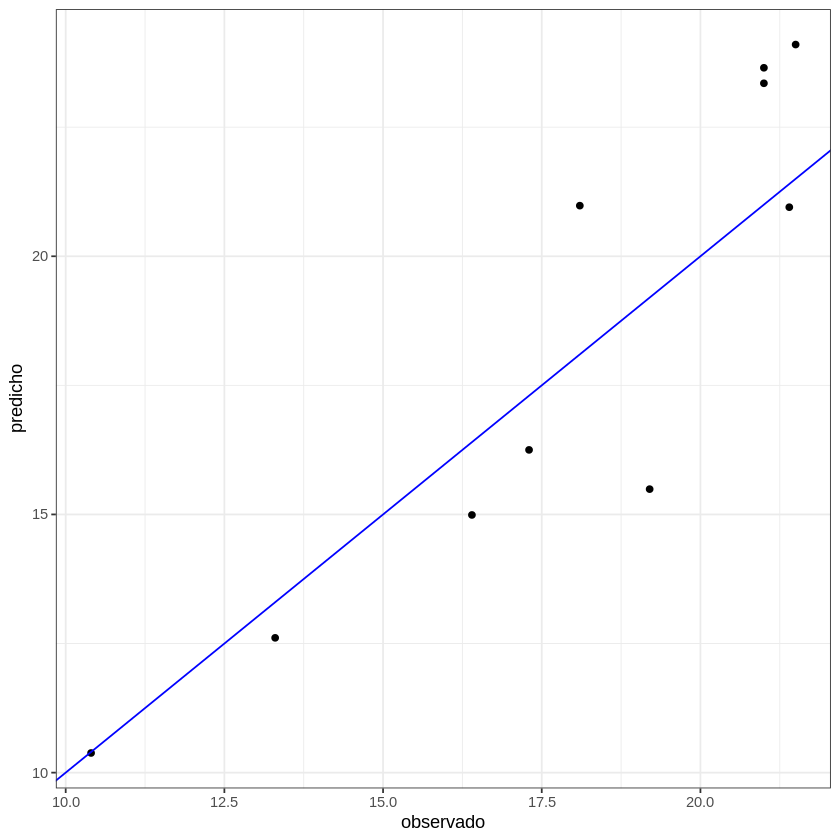

In [73]:
eval=data.frame(
  observado = test_lm$mpg,
  predicho = round(pred_test, 2)
)
eval
# ploteamos lo observado vs lo predicho por el modelo
ggplot(eval, aes(x = observado, y = predicho)) +
  geom_point() +
  geom_abline(color = "blue") + theme_bw()

### Comentarios

- `wt * am` equivale a `wt + am + wt:am`.
- Los gráficos diagnósticos ayudan a revisar linealidad, homocedasticidad y outlayers.
- En minería de datos conviene conectar el la inferenci con una evaluación predictiva simple.


### Ejercicios 3

1. Ajusta un modelo con interacción `mpg ~ wt * hp`.  
2. Revisa los diagnósticos del modelo.  
3. Divide el conjunto en train/test y calcula RMSE.  
4. Compara el RMSE entre el modelo con interacción y el modelo sin interacción.  
5. Discute cuál usarías para interpretar y cuál para predecir.



Call:
lm(formula = mpg ~ wt * am, data = mtcars2)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.6004 -1.5446 -0.5325  0.9012  6.0909 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  31.4161     3.0201  10.402 4.00e-11 ***
wt           -3.7859     0.7856  -4.819 4.55e-05 ***
amManual     14.8784     4.2640   3.489  0.00162 ** 
wt:amManual  -5.2984     1.4447  -3.667  0.00102 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.591 on 28 degrees of freedom
Multiple R-squared:  0.833,	Adjusted R-squared:  0.8151 
F-statistic: 46.57 on 3 and 28 DF,  p-value: 5.209e-11


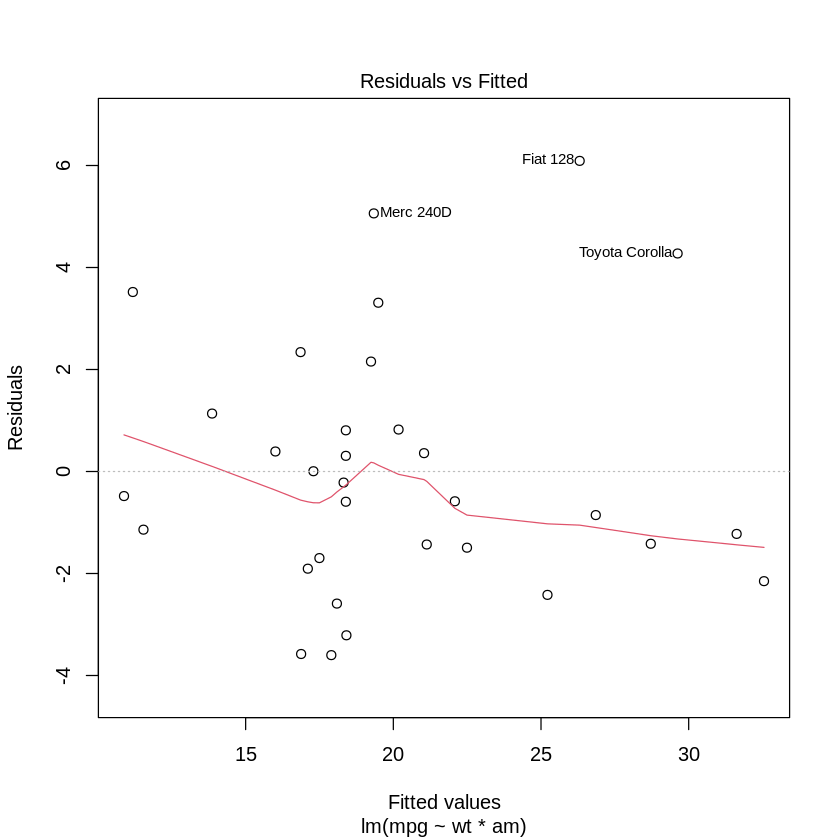

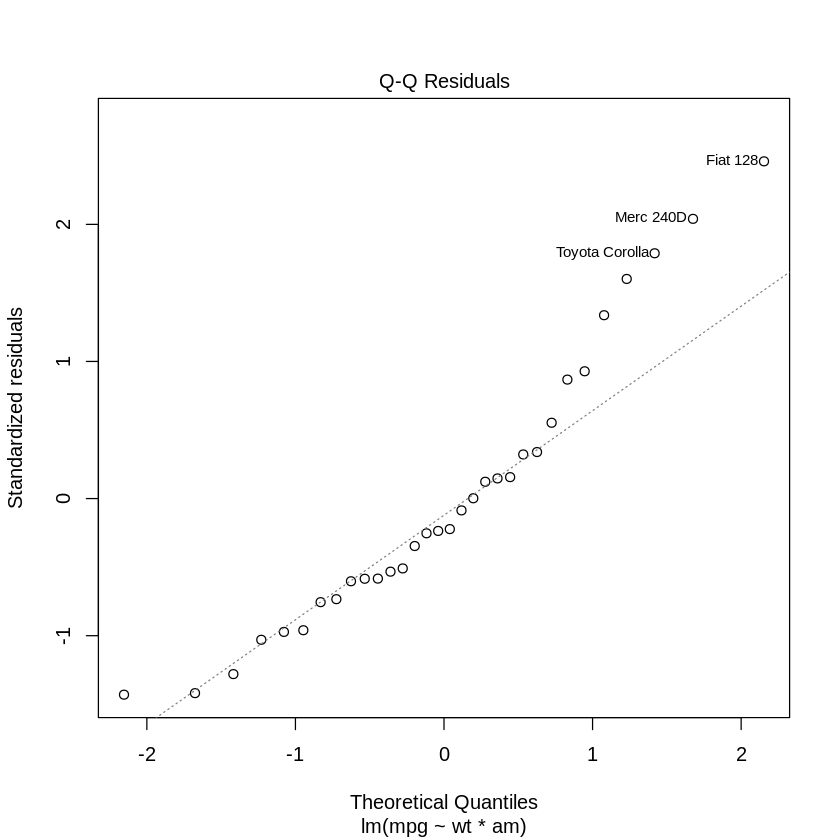

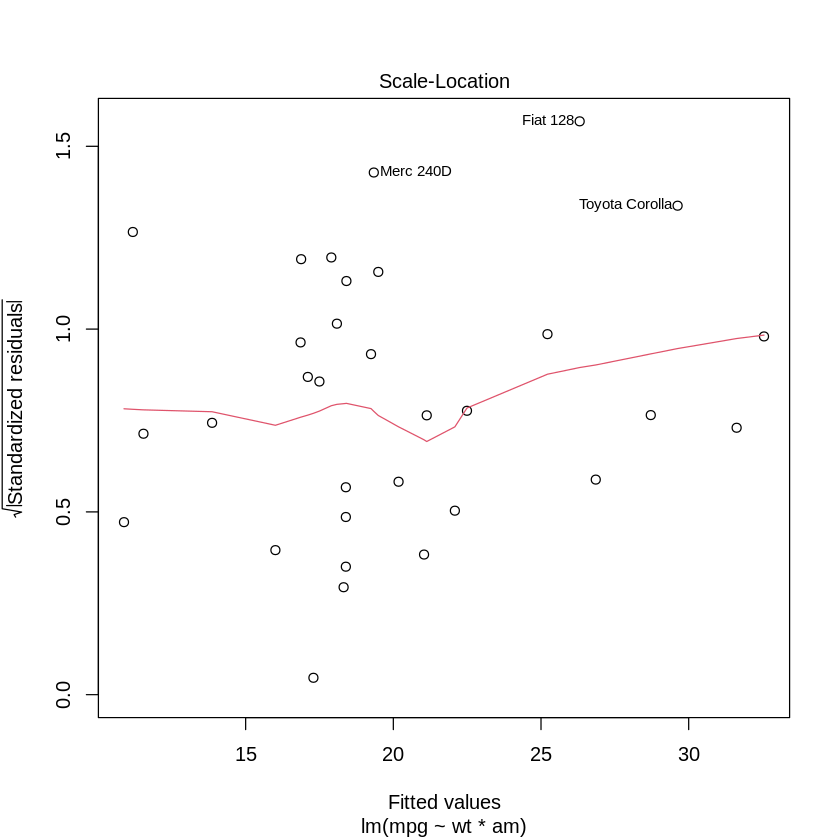

[1] 2.196789

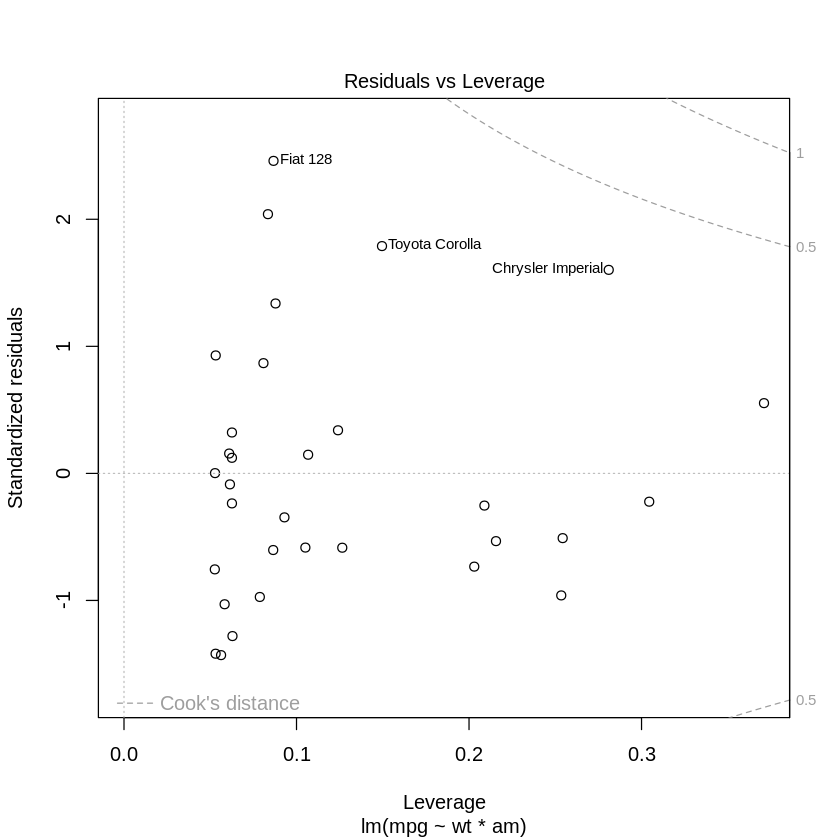

In [77]:
# Escribe aquí tu solución
modelo_int2 <- lm(mpg ~ wt * am, data = mtcars2)
summary(modelo_int2)
plot(modelo_int2)
#dividimos en datos de entrenamiento:
#entrenar el modelo con el 70% de los datos disponibles
idx_train <- sample(seq_len(nrow(mtcars2)), size = round(0.7 * nrow(mtcars2)))
#realizamos la particion de los datos en entrenamineto y test
train_lm <- mtcars2[idx_train, ]
test_lm  <- mtcars2[-idx_train, ]
#creamos el modelo
modelo_train <- lm(mpg ~ wt + hp + qsec + am, data = train_lm)
#evaluamos las predicciones del modelo
pred_test <- predict(modelo_train, newdata = test_lm)
#determinamos el error cuadratico medio
rmse <- function(obs, pred) sqrt(mean((obs - pred)^2))
rmse(test_lm$mpg, pred_test)




## 5. Introducción a la regresión logística

La regresión logística se usa cuando la respuesta es binaria:

- aprobar / reprobar
- enfermo / sano
- fraude / no fraude
- compra / no compra

En vez de modelar directamente la respuesta, el modelo trabaja sobre el logit de la probabilidad.


## 6. Regresión logística: ejemplo básico con `iris`

Crearemos una variable binaria:

- 1 = `setosa`
- 0 = `no setosa`


In [27]:
data(iris)

iris_log <- iris %>%
  mutate(is_setosa = ifelse(Species == "setosa", 1, 0))

head(iris_log)


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,is_setosa
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,5.1,3.5,1.4,0.2,setosa,1
2,4.9,3.0,1.4,0.2,setosa,1
3,4.7,3.2,1.3,0.2,setosa,1
4,4.6,3.1,1.5,0.2,setosa,1
5,5.0,3.6,1.4,0.2,setosa,1
6,5.4,3.9,1.7,0.4,setosa,1


In [28]:
modelo_logistico_1 <- glm(is_setosa ~ Sepal.Length + Sepal.Width,
                          family = binomial,
                          data = iris_log)

summary(modelo_logistico_1)

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = is_setosa ~ Sepal.Length + Sepal.Width, family = binomial, 
    data = iris_log)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept)     437.2   128737.9   0.003    0.997
Sepal.Length   -163.4    45394.8  -0.004    0.997
Sepal.Width     137.9    44846.1   0.003    0.998

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.9095e+02  on 149  degrees of freedom
Residual deviance: 2.7060e-08  on 147  degrees of freedom
AIC: 6

Number of Fisher Scoring iterations: 25


In [29]:
tidy(exp(coef(modelo_logistico_1)))


Warning message in tidy.numeric(exp(coef(modelo_logistico_1))):
“'tidy.numeric' is deprecated.
See help("Deprecated")”


names,x
<chr>,<dbl>
(Intercept),7.547721e+189
Sepal.Length,1.074480e-71
Sepal.Width,8.025273e+59


In [30]:
iris_log$prob_setosa <- predict(modelo_logistico_1, type = "response")
iris_log$pred_setosa <- ifelse(iris_log$prob_setosa >= 0.5, 1, 0)

table(Real = iris_log$is_setosa, Predicho = iris_log$pred_setosa)

mean(iris_log$is_setosa == iris_log$pred_setosa)


    Predicho
Real   0   1
   0 100   0
   1   0  50

[1] 1

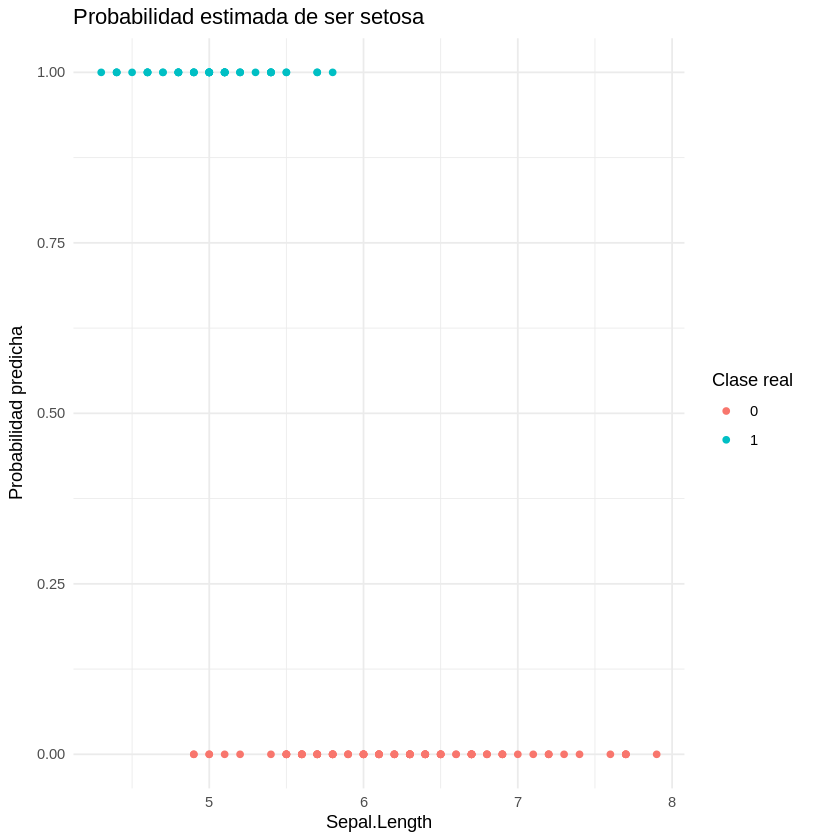

In [31]:
ggplot(iris_log, aes(x = Sepal.Length, y = prob_setosa, color = factor(is_setosa))) +
  geom_point() +
  labs(
    title = "Probabilidad estimada de ser setosa",
    x = "Sepal.Length",
    y = "Probabilidad predicha",
    color = "Clase real"
  ) +
  theme_minimal()


### Interpretación

- `predict(..., type = "response")` entrega probabilidades entre 0 y 1.
- `exp(coef(...))` entrega odds ratios.
- Un umbral común es 0.5, pero no siempre es el óptimo.


### Ejercicios 4

1. Ajusta un modelo usando también `Petal.Length` y `Petal.Width`.  
2. Compara el accuracy con el modelo actual.  
3. Cambia el umbral a 0.3 y a 0.7.  
4. Observa cómo cambia la matriz de confusión.  
5. Explica por qué el umbral afecta sensibilidad y especificidad.


In [32]:
# Escribe aquí tu solución
# modelo_log_ej <- glm(...)
# probs <- predict(..., type = "response")
# pred <- ifelse(probs >= 0.3, 1, 0)
# table(...)


## 7. Regresión logística intermedia: ejemplo interesante con `Titanic`

Usaremos un caso clásico: supervivencia en el Titanic.

El dataset `Titanic` viene agregado como tabla de frecuencias, por lo que ajustaremos un modelo logístico ponderado.


In [33]:
titanic_df <- as.data.frame(Titanic)
head(titanic_df)


,Class,Sex,Age,Survived,Freq
,<fct>,<fct>,<fct>,<fct>,<dbl>
1,1st,Male,Child,No,0
2,2nd,Male,Child,No,0
3,3rd,Male,Child,No,35
4,Crew,Male,Child,No,0
5,1st,Female,Child,No,0
6,2nd,Female,Child,No,0


In [34]:
modelo_titanic <- glm(
  Survived ~ Class + Sex + Age,
  family = binomial,
  weights = Freq,
  data = titanic_df
)

summary(modelo_titanic)


Call:
glm(formula = Survived ~ Class + Sex + Age, family = binomial, 
    data = titanic_df, weights = Freq)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.6853     0.2730   2.510   0.0121 *  
Class2nd     -1.0181     0.1960  -5.194 2.05e-07 ***
Class3rd     -1.7778     0.1716 -10.362  < 2e-16 ***
ClassCrew    -0.8577     0.1573  -5.451 5.00e-08 ***
SexFemale     2.4201     0.1404  17.236  < 2e-16 ***
AgeAdult     -1.0615     0.2440  -4.350 1.36e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2769.5  on 23  degrees of freedom
Residual deviance: 2210.1  on 18  degrees of freedom
AIC: 2222.1

Number of Fisher Scoring iterations: 5


In [35]:
tidy(exp(coef(modelo_titanic)))


Warning message in tidy.numeric(exp(coef(modelo_titanic))):
“'tidy.numeric' is deprecated.
See help("Deprecated")”


names,x
<chr>,<dbl>
(Intercept),1.9844057
Class2nd,0.3612825
Class3rd,0.1690159
ClassCrew,0.4241466
SexFemale,11.2465380
AgeAdult,0.3459219


Waiting for profiling to be done...



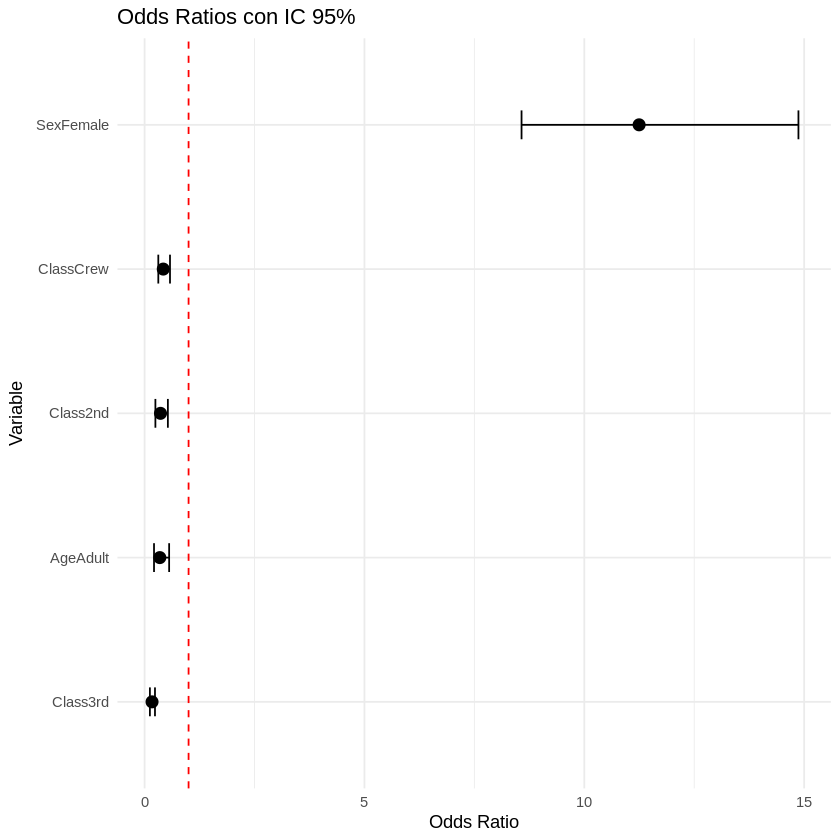

In [36]:
# Odds ratios e intervalos de confianza
or <- exp(coef(modelo_titanic))
ic <- exp(confint(modelo_titanic))

df_or <- data.frame(
  variable = names(or),
  odds_ratio = as.numeric(or),
  li = ic[,1],
  ls = ic[,2]
)

# Quitar intercepto
df_or <- subset(df_or, variable != "(Intercept)")

# Ordenar
df_or$variable <- factor(df_or$variable, levels = df_or$variable[order(df_or$odds_ratio)])


ggplot(df_or, aes(x = variable, y = odds_ratio)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = li, ymax = ls), width = 0.2) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    title = "Odds Ratios con IC 95%",
    x = "Variable",
    y = "Odds Ratio"
  ) +
  theme_minimal()

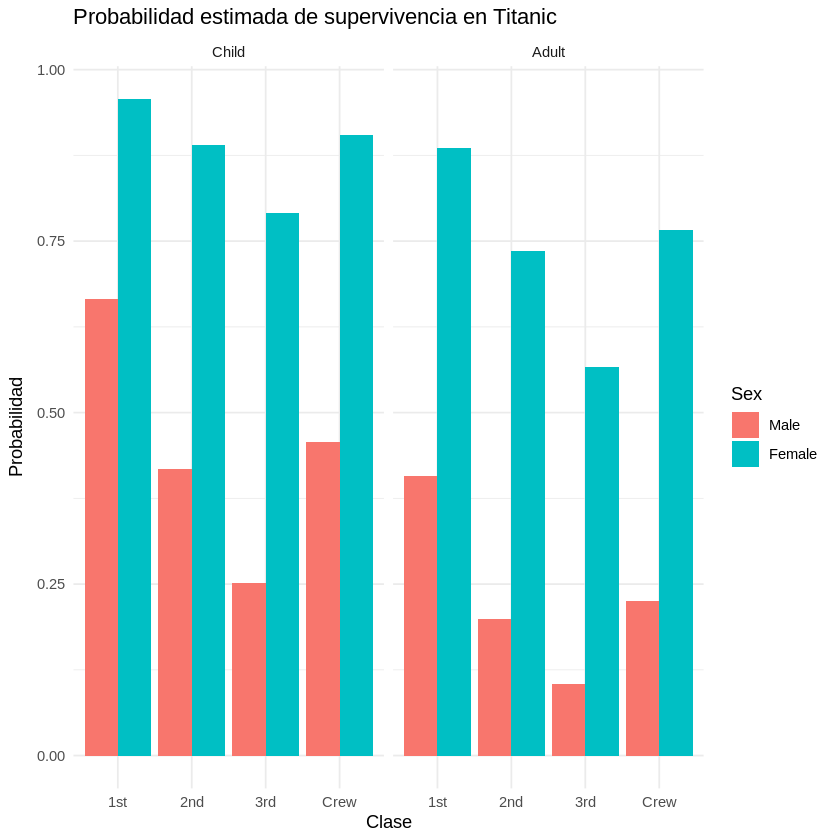

In [37]:

titanic_df$prob_surv <- predict(modelo_titanic, type = "response")

ggplot(titanic_df, aes(x = Class, y = prob_surv, fill = Sex)) +
  geom_col(position = "dodge") +
  facet_wrap(~ Age) +
  labs(
    title = "Probabilidad estimada de supervivencia en Titanic",
    x = "Clase",
    y = "Probabilidad"
  ) +
  theme_minimal()


### Qué muestra este ejemplo

- cómo incorporar predictores categóricos
- cómo interpretar odds ratios
- cómo usar pesos cuando los datos están agregados


### Ejercicios 5

1. Ajusta un modelo con interacción entre `Sex` y `Class`.  
2. Compara el AIC del modelo con y sin interacción.  
3. ¿La interacción mejora el ajuste?  
4. Interpreta el resultado en términos sustantivos.  
5. Grafica las probabilidades predichas del nuevo modelo.


In [38]:
# Escribe aquí tu solución
# modelo_titanic2 <- glm(...)
# AIC(modelo_titanic, modelo_titanic2)
# summary(modelo_titanic2)


## 8. Regresión logística avanzada: train/test, ROC y AUC

Ahora construiremos un problema más desafiante:

- 1 = `virginica`
- 0 = `versicolor`

Eliminamos `setosa` para que la clasificación no sea trivial.


In [39]:
iris_bin <- iris %>%
  filter(Species != "setosa") %>%
  mutate(is_virginica = ifelse(Species == "virginica", 1, 0))

table(iris_bin$is_virginica)


 0  1 
50 50 

Rows: 150
Columns: 5
$ Sepal.Length <dbl> 5.1, 4.9, 4.7, 4.6, 5.0, 5.4, 4.6, 5.0, 4.4, 4.9, 5.4, 4.…
$ Sepal.Width  <dbl> 3.5, 3.0, 3.2, 3.1, 3.6, 3.9, 3.4, 3.4, 2.9, 3.1, 3.7, 3.…
$ Petal.Length <dbl> 1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.…
$ Petal.Width  <dbl> 0.2, 0.2, 0.2, 0.2, 0.2, 0.4, 0.3, 0.2, 0.2, 0.1, 0.2, 0.…
$ Species      <fct> setosa, setosa, setosa, setosa, setosa, setosa, setosa, s…


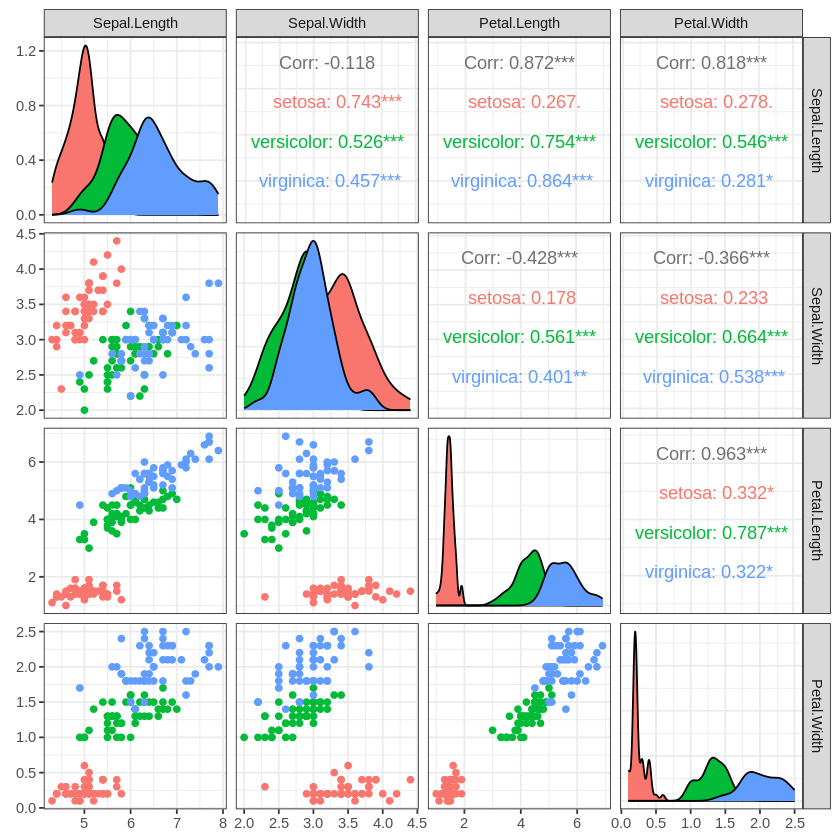

In [40]:
glimpse(iris)
#iris %>% ggplot(aes(x=))
#ggpairs(iris, 1:4, ggplot2::color)
ggpairs(iris, columns = 1:4, ggplot2::aes(colour = Species)) + theme_bw()

In [41]:
set.seed(123)
idx <- sample(seq_len(nrow(iris_bin)), size = round(0.7 * nrow(iris_bin)))

train_glm <- iris_bin[idx, ]
test_glm  <- iris_bin[-idx, ]

modelo_logistico_2 <- glm(
  is_virginica ~ Sepal.Width  + Sepal.Length,
  family = binomial,
  data = train_glm
)

summary(modelo_logistico_2)



Call:
glm(formula = is_virginica ~ Sepal.Width + Sepal.Length, family = binomial, 
    data = train_glm)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -13.8725     3.8496  -3.604 0.000314 ***
Sepal.Width    0.9177     1.0080   0.910 0.362607    
Sepal.Length   1.8142     0.6437   2.818 0.004829 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 97.041  on 69  degrees of freedom
Residual deviance: 77.956  on 67  degrees of freedom
AIC: 83.956

Number of Fisher Scoring iterations: 4


In [42]:
test_glm$prob <- predict(modelo_logistico_2, newdata = test_glm, type = "response")
test_glm$pred <- ifelse(test_glm$prob >= 0.5, 1, 0)

matriz_conf <- table(Real = test_glm$is_virginica, Predicho = test_glm$pred)
matriz_conf

accuracy <- mean(test_glm$is_virginica == test_glm$pred)
accuracy


    Predicho
Real  0  1
   0  9  6
   1  1 14

[1] 0.7666667

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.7711

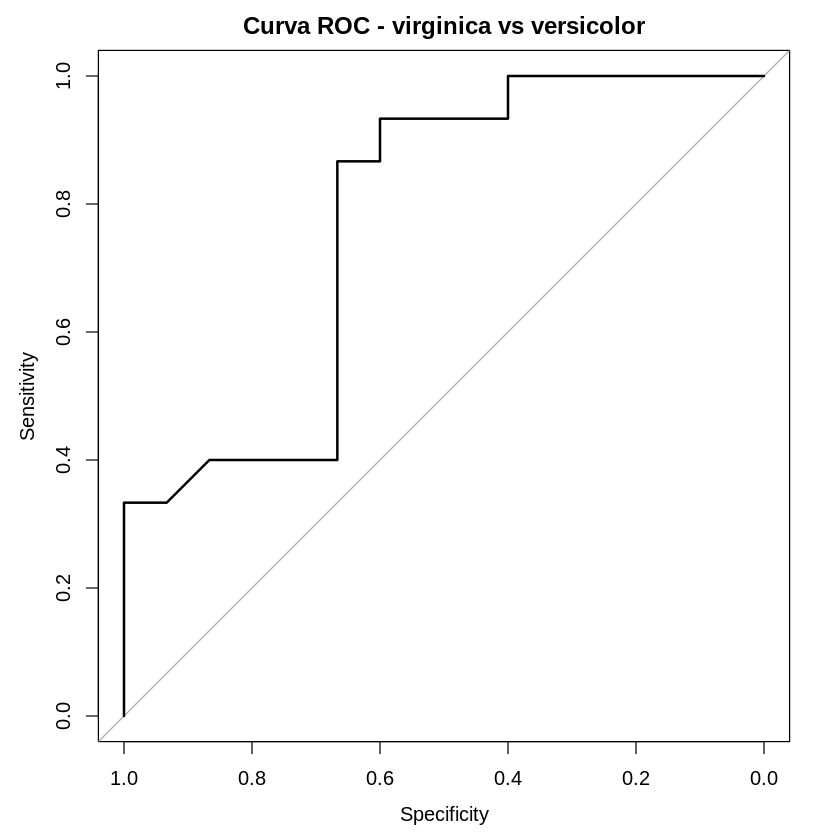

In [43]:
roc_obj <- roc(test_glm$is_virginica, test_glm$prob)
auc(roc_obj)
plot(roc_obj, main = "Curva ROC - virginica vs versicolor")


In [44]:
modelo_reducido <- glm(
  is_virginica ~ Petal.Length,
  family = binomial,
  data = train_glm
)
#The smaller the AIC value, the better the model performance is
AIC(modelo_reducido, modelo_logistico_2)


,df,AIC
,<dbl>,<dbl>
modelo_reducido,2,29.01670
modelo_logistico_2,3,83.95618


### Ideas clave

- La matriz de confusión depende del umbral.
- La curva ROC resume el desempeño del clasificador en todos los umbrales.
- El AUC mide la capacidad de discriminación del modelo.
- Un modelo más complejo no siempre mejora mucho respecto a uno más simple.


### Ejercicios 6

1. Cambia el umbral a 0.4 y 0.6.  
2. Calcula nuevamente la matriz de confusión y accuracy.  
3. Compara el modelo completo con uno reducido.  
4. ¿Qué variables parecen más útiles?  
5. ¿Qué preferirías: un modelo más interpretable o uno con mejor AUC?


In [78]:

# Escribe aquí tu solución
# test_glm$pred_04 <- ifelse(test_glm$prob >= 0.4, 1, 0)
# table(...)
# ...


## 9. Mini proyecto integrador

### Parte A: modelo lineal

Usa `mtcars` y responde:

> ¿Qué variables explican mejor el consumo de combustible (`mpg`)?

### Parte B: modelo logístico

Usa `iris` o `Titanic` y plantea una tarea de clasificación binaria.

Sugerencias:

1. define la variable respuesta  
2. ajusta el modelo  
3. genera probabilidades predichas  
4. construye la matriz de confusión  
5. si puedes, calcula ROC y AUC  
6. redacta una breve conclusión


In [ ]:
# Usa esta celda para desarrollar tu mini proyecto


## 10. Resumen final

En este notebook revisamos:

- ajustar modelos lineales simples y múltiples con `lm()`
- interpretar coeficientes, significancia y $R^2$
- incorporar variables categóricas e interacciones
- revisar diagnóstico de residuos
- usar validación simple train/test
- ajustar modelos logísticos con `glm(..., family = binomial)`
- obtener probabilidades predichas
- construir matrices de confusión
- usar ROC y AUC para evaluar clasificadores

### Funciones clave

- `lm()`
- `glm(..., family = binomial)`
- `summary()`
- `predict()`
- `anova()`
- `tidy()` y `glance()`
- `roc()` y `auc()`
